### EAGLE-AI: three-shot agentic failure mode analysis
### Julian Moran
### 2026-05-18

In [1]:
import os
import logging

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import polars as pl

from dotenv import load_dotenv
from matplotlib import colors as mcolors
from matplotlib.colors import Colormap

# Logging
logging.basicConfig(
    level=logging.INFO,
    format="%(levelname)s:%(name)s:%(message)s"
)
logger = logging.getLogger(__name__)

In [2]:
# ============================================================
#   Args
# ============================================================

load_dotenv("../.env", override=True)
REPO_ROOT = os.getenv("REPO_ROOT")
OUT_DIR = f"./"
DATA_PERFORMANCE = f"./___EAGLE-AI_performance_bound.tsv"
COL_FAIL_REASON = "score_diff_reason"
COL_FAIL_SUBREASON = "score_diff_sub_reason"

In [3]:
# ============================================================
#   In
# ============================================================

df = pl.read_csv(
            DATA_PERFORMANCE,
            has_header=True,
            separator="\t",
            infer_schema_length=10000,
            null_values="NA"
        )

df

publication,gene,curator_assigned_case_id,eagle-ai_assigned_case_id,case_in_eagle,case_id_match,curator_assigned_variant_id,eagle-ai_variant_id,variant_in_eagle,variant_enough_info,variant_id_match,phenotype_accuracy_rating,manual_score,eagle_ai_score,score_diff
str,str,str,str,str,bool,str,str,str,bool,bool,f64,f64,f64,f64
"""tassinari_2023""","""CDKL5""","""mouse_KO_wang_2012""",null,"""FN""",false,null,null,null,null,null,null,2.0,0.0,2.0
"""tassinari_2023""","""CDKL5""","""mouse_KO_ren_2019""","""CDD_Mouse_Model_01""","""TP""",false,null,null,null,null,null,null,2.0,3.0,1.0
"""tassinari_2023""","""CDKL5""","""mouse_KO_amendola_2014""",null,"""TN""",false,null,null,null,null,null,null,0.0,0.0,0.0
"""khan_2024""","""CDKL5""","""PKASD-18""","""PKASD-18""","""TP""",true,"""NM_003159.3:c.2626A>G""","""NM_003159.3:c.2626A>G; p.Ile87…","""TP""",true,false,8.0,0.1,0.1,0.0
"""khan_2024""","""CDKL5""","""codina_sola_CDKL5_P1""",null,"""FN""",false,"""p.Pro647Leu""",null,"""FN""",false,false,null,0.1,0.0,0.1
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""becker_2022""","""CASK""","""becker_2020_2018ASD_twin_2""",null,"""TN""",null,null,null,null,null,null,null,0.0,0.0,0.0
"""becker_2024""","""CASK""","""becker_2020_2018_ID_P1""",null,"""TN""",null,null,null,null,null,null,null,0.0,0.0,0.0
"""seto_2017""","""CASK""","""seto_2017_P1""","""Patient 1""","""TP""",false,"""NM_003688.3:c.1424G>T""","""chrX:41437672C>A, NM_003688.3(…","""TP""",true,false,8.0,0.1,0.5,0.4


In [49]:
# ============================================================
#   Filter
# ============================================================

df_filt = df.filter(
    (pl.col("score_diff") > 0)
)

df_filt
logger.info(f"Nrows after score_diff filter: {len(df_filt)}")

# Quality check
df_tmp = df_filt.filter(
    pl.col(COL_FAIL_REASON).is_not_null()
)
logger.info(f"Nrows after score_diff_reason filter: {len(df_tmp)}")

df_filt

INFO:__main__:Nrows after score_diff filter: 37
INFO:__main__:Nrows after score_diff_reason filter: 37


publication,gene,curator_assigned_case_id,eagle-ai_assigned_case_id,case_in_eagle,case_id_match,curator_assigned_variant_id,eagle-ai_variant_id,variant_in_eagle,variant_enough_info,variant_id_match,phenotype_accuracy_rating,manual_score,eagle_ai_score,score_diff,score_diff_reason,score_diff_sub_reason,reason_explanation
str,str,str,str,str,bool,str,str,str,bool,bool,i64,f64,f64,f64,str,str,str
"""tassinari_2023""","""CDKL5""","""mouse_KO_wang_2012""",null,"""FN""",false,null,null,null,null,null,null,2.0,0.0,2.0,"""missed_case""","""missed_external_paper""","""The mouse model seen here is o…"
"""tassinari_2023""","""CDKL5""","""mouse_KO_ren_2019""","""CDD_Mouse_Model_01""","""TP""",false,null,null,null,null,null,null,2.0,3.0,1.0,"""discretion""","""discretion""",null
"""khan_2024""","""CDKL5""","""codina_sola_CDKL5_P1""",null,"""FN""",false,"""p.Pro647Leu""",null,"""FN""",false,false,null,0.1,0.0,0.1,"""missed_case""","""bad_table_parsing""",null
"""khan_2024""","""CDKL5""","""MSSNG_CDK1L5_P1""",null,"""FN""",false,"""NM_003159:c.16A>G""",null,"""FN""",false,false,null,0.1,0.0,0.1,"""missed_case""","""missed_external_paper""",null
"""khan_2024""","""CDKL5""","""MSSNG_CDK1L5_P2""",null,"""FN""",false,"""NM_003159:c.92G>A""",null,"""FN""",false,false,null,0.1,0.0,0.1,"""missed_case""","""missed_supplementary""",null
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""li_2025""","""CHAMP1""","""GM27912""",null,"""FP""",false,null,null,null,null,null,null,0.0,2.0,2.0,"""failed_logic""","""ignored_phenotype_details""",null
"""becker_2020""","""CASK""","""becker_2020_ASD_twin_1""","""ASDCASK_SS_CASK_c.1296+1G>T""","""TP""",false,"""NM_001126055:c1296+1G>T""","""chrX:41,586,906 C>A (hg38); NM…","""TP""",true,false,10,2.5,2.0,0.5,"""missed_phenotype_details""","""missed_external_paper""",null
"""seto_2017""","""CASK""","""seto_2017_P1""","""Patient 1""","""TP""",false,"""NM_003688.3:c.1424G>T""","""chrX:41437672C>A, NM_003688.3(…","""TP""",true,false,8,0.1,0.5,0.4,"""failed_logic; missed_phenotype…","""ignored_variant_details; ignor…",null


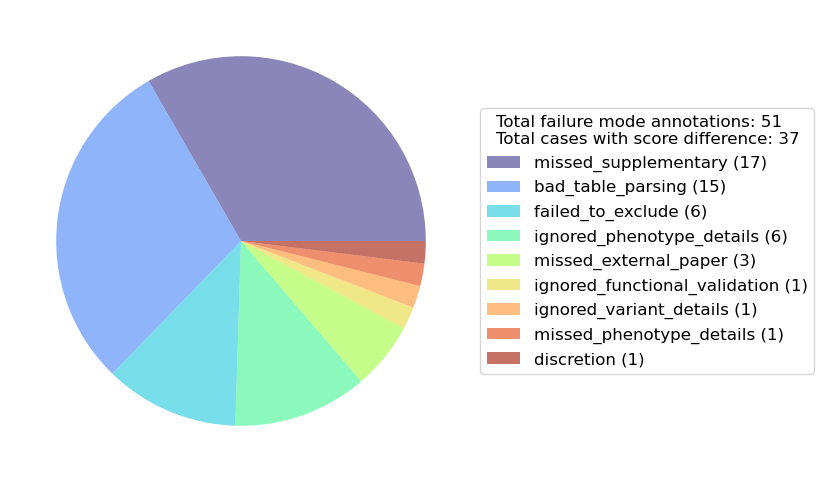

In [50]:
# ============================================================
#   Pie plot
# ============================================================

def pie_chart(
        data: pl.DataFrame,
        col: str,
        cmap: Colormap = plt.colormaps["viridis"],
        dims: tuple = (6, 6),
        title: str = "",
        title_font_size: int = 12,
        label_font_size: int = 12,
        alpha: float = 0.6,
        out_name: str = ""
    ):

    exploded = (
        data
        .select(pl.col(col).cast(pl.Utf8))
        .with_columns(pl.col(col).str.split(";"))
        .explode(col)
        .with_columns(pl.col(col).str.strip_chars())
    )
    counts_df = (
        exploded
        .group_by(col)
        .len()
        .sort("len", descending=True)
    )
    labels = counts_df[col].to_list()
    counts = np.array(counts_df["len"].to_list())
    n = len(counts)
    colors = cmap(np.linspace(0.05, 0.95, n))
    colors[:, 3] = alpha

    fig, ax = plt.subplots(figsize=dims)
    ax.pie(
        counts,
        labels=None,
        colors=colors
    )
    legend = ax.legend(
        [f"{l} ({c})" for l, c in zip(labels, counts)],
        title=f"Total failure mode annotations: {len(exploded)}\nTotal cases with score difference: {len(data)}",
        loc="center left",
        bbox_to_anchor=(1.0, 0.5),
        fontsize=label_font_size
    )
    legend.get_title().set_fontsize(label_font_size)
    ax.set_title(title, fontsize=title_font_size)

    if out_name:
        out_name = out_name.replace(" ", "_")
        fig.savefig(f"{out_name}.svg", bbox_inches="tight")
        fig.savefig(f"{out_name}.png", bbox_inches="tight", dpi=300)

    plt.show()

pie_chart(
    data=df_filt,
    col=COL_FAIL_SUBREASON,
    cmap=plt.colormaps["turbo"],
    alpha=0.6,
    out_name=f"{OUT_DIR}/EAGLE-AI-dataExtraction_manu_failMode"
)